# Activity 2 — Ridgelines: Many Distributions at Once
**DSC 402/502 · Distributions.** One density ridge per month. You’ll compare it to a boxplot and faceted histograms, and learn that **ordering the rows** is the make-or-break design choice.

> **This activity borrows R for one chart** — `ggridges` is the canonical ridgeline package (written by Claus Wilke, the author of our textbook). Run the setup cells first; the install takes ~1–2 min.

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages('ggridges')   # ~1-2 min the first time
library(ggridges); library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggridges_0.5.7.tar.gz'
Content type 'application/x-gzip' length 2210918 bytes (2.1 MB)
downloaded 2.1 MB


The downloaded source packages are in
	‘/tmp/RtmpEFqvew/downloaded_packages’


### Get the data — real daily highs for Flint
Pulls actual daily high temps from the Open-Meteo historical archive (free, no key). If the live call fails, it falls back to a simulated set around Flint’s real monthly normals — so this cell **always** produces `temps` and class never blocks.

In [ ]:
import pandas as pd, numpy as np

def load_flint_daily():
    try:
        import requests
        r = requests.get('https://archive-api.open-meteo.com/v1/archive', params={
            'latitude':42.97,'longitude':-83.74,
            'start_date':'2020-01-01','end_date':'2024-12-31',
            'daily':'temperature_2m_max','temperature_unit':'fahrenheit',
            'timezone':'America/Detroit'}, timeout=30).json()
        t = pd.DataFrame({'date':pd.to_datetime(r['daily']['time']),
                          'high_f':r['daily']['temperature_2m_max']}).dropna()
        t['month'] = t['date'].dt.strftime('%b')
        return t[['month','high_f']], 'real (Open-Meteo 2020-2024)'
    except Exception as e:
        months=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
        highs=[29.9,32.8,43.3,56.7,68.9,78.2,82.1,79.9,73.1,60.1,46.6,34.9]
        sd=[9,9,10,9,8,7,6,6,7,8,8,9]; days=[31,28,31,30,31,30,31,31,30,31,30,31]
        rng=np.random.default_rng(42); rows=[]
        for m,h,s,dn in zip(months,highs,sd,days):
            for v in rng.normal(h,s,dn).round().astype(int): rows.append({'month':m,'high_f':int(v)})
        return pd.DataFrame(rows), 'simulated fallback'

temps, source = load_flint_daily()
print('Data source:', source, '| rows:', len(temps))
temps.head()

Data source: real (Open-Meteo 2020-2024) | rows: 1827


,month,high_f
0,Jan,36.4
1,Jan,46.6
2,Jan,41.5
3,Jan,35.4
4,Jan,35.7


### 1. Build the ridgeline
Read the *shape*: where is the year’s spread widest? Where do ridges bunch up?

Picking joint bandwidth of 2.84


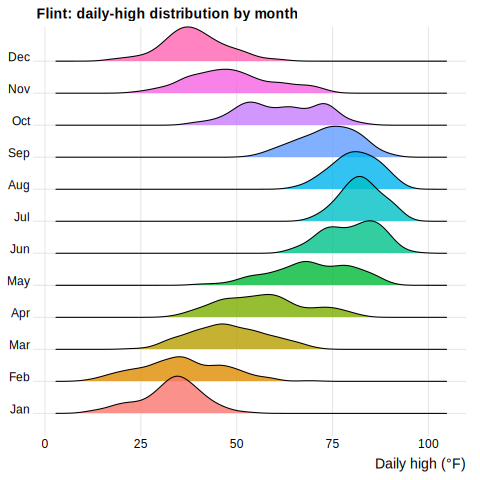

In [ ]:
%%R -i temps
temps$month <- factor(temps$month,
  levels=c('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'))
ggplot(temps, aes(x=high_f, y=month, fill=month)) +
  geom_density_ridges(alpha=0.8, scale=1.4) +
  theme_ridges() + theme(legend.position='none') +
  labs(x='Daily high (°F)', y=NULL, title='Flint: daily-high distribution by month')

### 2. Change the overlap
**# YOUR TURN:** raise and lower `scale` (e.g. 0.8 vs 2.5). Find where more overlap starts *hiding* each ridge’s baseline. Which value do you prefer?

Picking joint bandwidth of 2.84


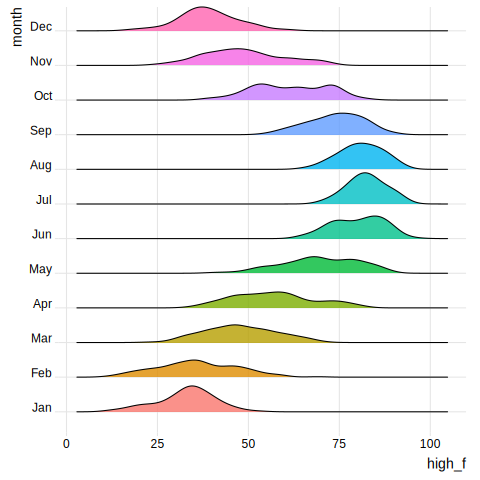

In [ ]:
%%R
# YOUR TURN: change scale = ...
ggplot(temps, aes(x=high_f, y=month, fill=month)) +
  geom_density_ridges(alpha=0.8, scale=0.9) + theme_ridges() + theme(legend.position='none')


### 3. Reorder the rows
**# YOUR TURN:** order months **by median temperature** instead of calendar order (`y = reorder(month, high_f, median)`). Which ordering tells a clearer story? and *what* story does each tell?

Picking joint bandwidth of 2.84


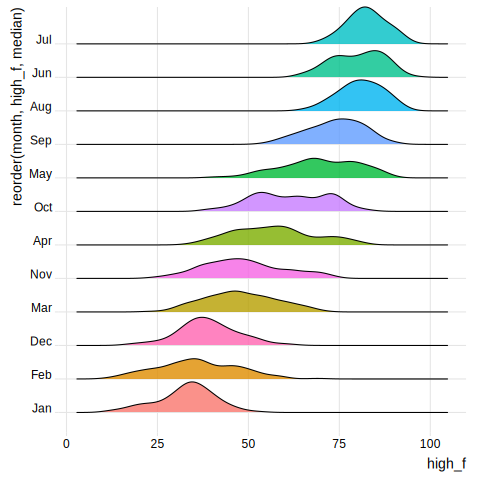

In [ ]:
%%R
# YOUR TURN: reorder by median
ggplot(temps, aes(x=high_f, y=reorder(month, high_f, median), fill=month)) +
  geom_density_ridges(alpha=0.8, scale=1.1) + theme_ridges() + theme(legend.position='none')


### 4. Compare against two other displays
**# YOUR TURN:** make a **boxplot** (`geom_boxplot` for ggplot) and **faceted histograms** (`geom_histogram` + `facet_wrap(~month)`) of the same data. For each, note one thing it shows *better* than the ridgeline and one thing *worse*.

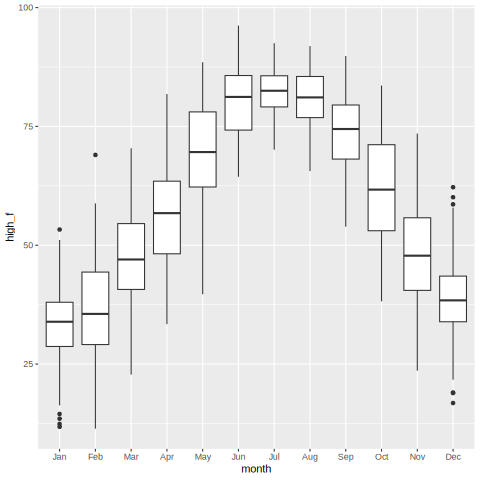

In [ ]:
%%R
# YOUR TURN: boxplot and/or faceted histograms
ggplot(temps, aes(x=month, y=high_f)) +
    geom_boxplot()


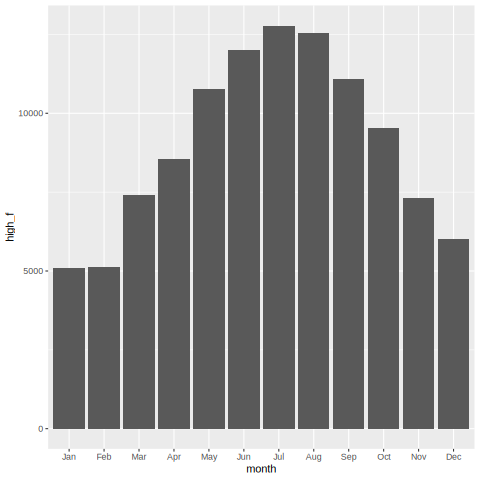

In [ ]:
%%R
ggplot(temps, aes(x=month, y=high_f)) +
    geom_col()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


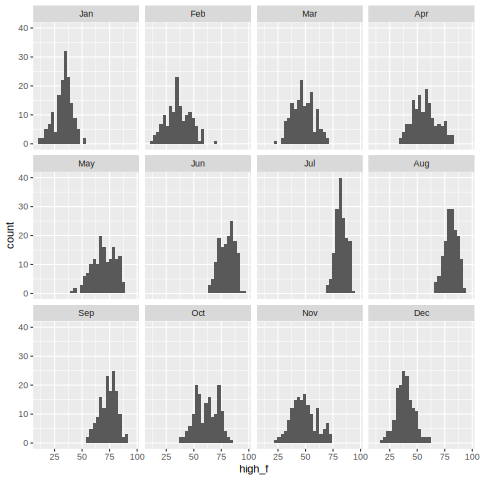

In [ ]:
%%R
ggplot(temps, aes(x=high_f)) +
    geom_histogram() + facet_wrap(~month)